# Synthetic Model Generator

- tensor (discretization)
- topography
- density map
- survey

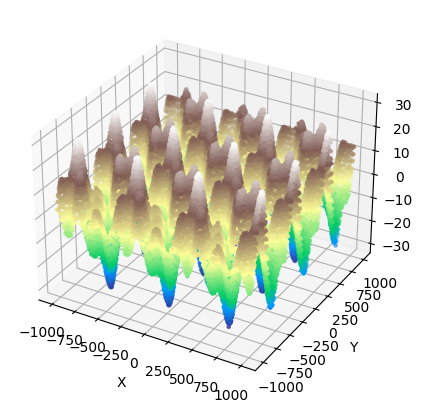

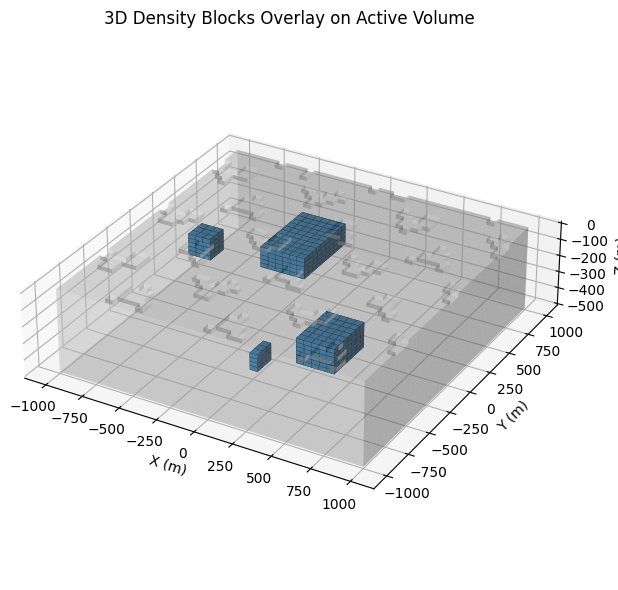

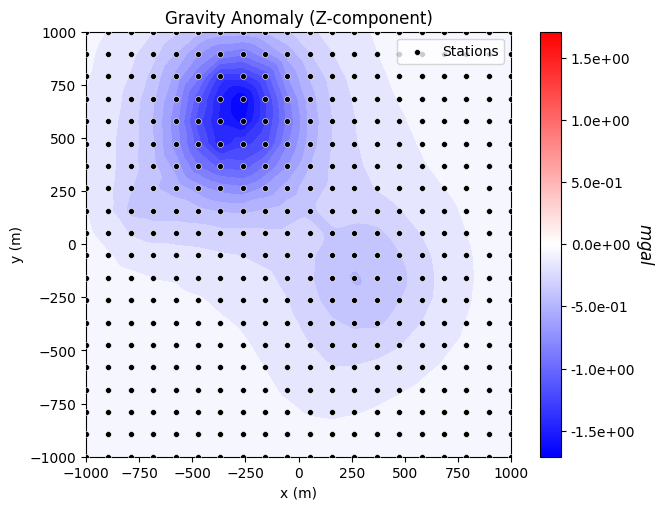

In [1]:
import numpy as np
from scipy.interpolate import LinearNDInterpolator
from simpeg import maps
from simpeg.potential_fields import gravity
from simpeg.utils import model_builder
from discretize import TensorMesh
from discretize.utils import mkvc, active_from_xyz
from simpeg import (
    maps,
    data,
    data_misfit,
    inverse_problem,
    regularization,
    optimization,
    directives,
    inversion,
    utils,
)
from src.plotter import plot_topography, plot_density_contrast_2D, plot_density_contrast_3D, plot_density_contrast_3D_voxels, plot_gravity_measurements


def synthetic_topography(
    x_min=-1000, x_max=1000,
    y_min=-1000, y_max=1000,
    dx=10, dy=10,
    base_level=0.0,
    fbm_amp=20.0,
    seed=4,
    noise_sigma=0.5,
):
    """
    Return (N,3) array of x,y,z points representing synthetic topography.

    Parameters
    ----------
    x_min, x_max, y_min, y_max : float
        Domain bounds.
    dx, dy : float
        Sampling grid spacing.
    base_level : float
        Base elevation (meters).
    fbm_amp : float
        Relief amplitude (meters).
    seed : int
        RNG seed.
    noise_sigma : float
        Std deviation of Gaussian noise on z.

    Returns
    -------
    xyz : ndarray, shape (N,3)
        Point cloud of synthetic topography.
    """
    rng = np.random.default_rng(seed)

    xs = np.arange(x_min, x_max + 1e-9, dx)
    ys = np.arange(y_min, y_max + 1e-9, dy)
    X, Y = np.meshgrid(xs, ys, indexing="xy")

    # synthetic hills from sinusoids
    Z = base_level + fbm_amp * (
        np.sin(0.01*X + seed) * np.cos(0.01*Y + seed/2)
        + 0.5*np.sin(0.03*X) * np.cos(0.02*Y)
    )

    # add noise
    Z += rng.normal(0.0, noise_sigma, size=Z.shape)

    # flatten
    XX, YY, ZZ = mkvc(X), mkvc(Y), mkvc(Z)

    return np.c_[XX, YY, ZZ]


def create_mesh(topo_xyz, n_xy=40, n_z=20, z_down=500.0):
    """
    Create a TensorMesh based on topography points.
    Parameters
    ----------
    topo_xyz : np.ndarray
        Topography XYZ locations.
    n_xy : int
        Number of cells in x and y directions.
    n_z : int
        Number of cells in z direction.
    z_down : float
        Depth extent (downwards).
    """
    x_min, x_max = float(topo_xyz[:,0].min()), float(topo_xyz[:,0].max())
    y_min, y_max = float(topo_xyz[:,1].min()), float(topo_xyz[:,1].max())
    Lx = x_max - x_min
    Ly = y_max - y_min
    # choose square lateral extent = max(Lx, Ly)
    L = max(Lx, Ly)
    hx = [(L / n_xy, n_xy)]
    hy = [(L / n_xy, n_xy)]
    hz = [(z_down / n_z, n_z)]   # depth extent (downwards)
    mesh = TensorMesh([hx, hy, hz], "CCN")  # centered in x,y; z goes negative
    return mesh


def initialize_model_and_active_cells(mesh, topo_xyz, background_density=0.0):
    """
    Initialize the density model and active cell indices.

    Parameters
    ----------
    mesh : discretize.TensorMesh
        The mesh object.
    topo_xyz : np.ndarray
        Topography XYZ locations.
    background_density : float, optional
        Background density value (default is 0.0).

    Returns
    -------
    ind_active : np.ndarray
        Boolean array of active cells.
    nC : int
        Number of active cells.
    model_map : simpeg.maps.IdentityMap
        Identity map for the model.
    true_model : np.ndarray
        Initialized model array.
    """
    ind_active = active_from_xyz(mesh, topo_xyz)
    nC = int(ind_active.sum())
    model_map = maps.IdentityMap(nP=nC)
    true_model = background_density * np.ones(nC)
    return ind_active, nC, model_map, true_model


def add_random_blocks(
    mesh,
    ind_active,
    base_model=None,
    n_blocks=4,
    size_frac_range=(0.05, 0.30),     # each block spans 5–30% of domain per axis
    density_range=(0, 2),     # g/cc; choose negatives for density deficit
    seed=90,
    max_tries=200,
    enforce_nonoverlap=True,
):
    """
    Returns (model, blocks_mask) where:
      - model is a copy of base_model (or zeros) with random blocks painted in
      - blocks_mask is a boolean mask (on active cells) of all block cells
    """
    rng = np.random.default_rng(seed)
    # Active cell centers (x, y, z)
    CCa = mesh.gridCC[ind_active]  # shape (n_active, 3)
    x, y, z = CCa[:, 0], CCa[:, 1], CCa[:, 2]
    x_min, x_max = float(x.min()), float(x.max())
    y_min, y_max = float(y.min()), float(y.max())
    z_min, z_max = float(z.min()), float(z.max())

    Lx, Ly, Lz = x_max - x_min, y_max - y_min, z_max - z_min
    # Start from provided base_model or zeros
    if base_model is None:
        model = np.zeros(ind_active.sum(), dtype=float)
    else:
        model = base_model.copy()

    # Track “occupied” cells if we want non-overlap
    occupied = np.zeros_like(model, dtype=bool)

    for k in range(n_blocks):
        placed = False
        for _ in range(max_tries):
            # Random physical sizes (axis-aligned prisms)
            fx = rng.uniform(*size_frac_range)
            fy = rng.uniform(*size_frac_range)
            fz = rng.uniform(*size_frac_range)
            sx, sy, sz = fx * Lx, fy * Ly, fz * Lz

            # Guard tiny or degenerate sizes
            if sx <= 0 or sy <= 0 or sz <= 0:
                continue

            # Random centers (keep the full block inside domain extents)
            cx = rng.uniform(x_min + sx / 2, x_max - sx / 2)
            cy = rng.uniform(y_min + sy / 2, y_max - sy / 2)
            cz = rng.uniform(z_min + sz / 2, z_max - sz / 2)

            # Axis-aligned bounds
            x0, x1 = cx - sx / 2, cx + sx / 2
            y0, y1 = cy - sy / 2, cy + sy / 2
            z0, z1 = cz - sz / 2, cz + sz / 2

            # Boolean mask on *active* cells only
            mask_k = (
                (x >= x0) & (x <= x1) &
                (y >= y0) & (y <= y1) &
                (z >= z0) & (z <= z1)
            )

            # Ensure we actually captured some cells below the surface
            if mask_k.sum() == 0:
                continue

            # Optionally avoid overlap with previous blocks
            if enforce_nonoverlap and np.any(occupied & mask_k):
                continue

            dens_k = rng.uniform(*density_range)  # g/cc
            model[mask_k] = dens_k
            occupied |= mask_k
            placed = True
            break

        if not placed:
            print(f"[warn] Block {k+1}/{n_blocks} could not be placed after {max_tries} tries.")

    return model, occupied


def gravity_survey(
    x_bounds,
    y_bounds,
    topo_xyz,
    dh=5.0,
    n_points=20,
    # components=["gz"]
):
    """
    Create gravity survey locations and SimPEG survey objects from topography.

    Parameters
    ----------
    x_bounds : tuple
        (min, max) bounds for x locations (meters).
    y_bounds : tuple
        (min, max) bounds for y locations (meters).
    topo_xyz : ndarray, shape (N, 3)
        Topography points.
    dh : float
        Height above topography for receivers (meters).
    n_points : int
        Number of points per axis for grid.
    components : list
        Gravity components (default ["gz"]).

    Returns
    -------
    receiver_locations : ndarray
        (N, 3) array of receiver locations.
    receiver_list : list
        List of SimPEG gravity receivers.
    source_field : SimPEG gravity SourceField
    survey : SimPEG gravity Survey

    Notes
    -----
    All units are in meters.
    """
    x = np.linspace(x_bounds[0], x_bounds[1], n_points)
    y = np.linspace(y_bounds[0], y_bounds[1], n_points)
    x, y = np.meshgrid(x, y)
    x, y = mkvc(x.T), mkvc(y.T)
    x_topo, y_topo, z_topo = topo_xyz[:, 0], topo_xyz[:, 1], topo_xyz[:, 2]
    fun_interp = LinearNDInterpolator(np.c_[x_topo, y_topo], z_topo)
    z = fun_interp(np.c_[x, y]) + dh
    receiver_locations = np.c_[x, y, z]
    components = ["gz"]

    receiver_list = gravity.receivers.Point(receiver_locations, components=components)
    receiver_list = [receiver_list]
    source_field = gravity.sources.SourceField(receiver_list=receiver_list)
    survey = gravity.survey.Survey(source_field)
    return receiver_locations, receiver_list, source_field, survey

if __name__ == "__main__":
    topo_xyz = synthetic_topography()

    mesh = create_mesh(topo_xyz)

    ind_active, nC, model_map, true_model = initialize_model_and_active_cells(mesh, topo_xyz)

    true_model, blocks_mask = add_random_blocks(
        mesh=mesh,
        ind_active=ind_active,
        base_model=true_model,     # start from your background model
        n_blocks=4,
        size_frac_range=(0, 0.3),   # tweak as you like
        density_range=(0, 2),   # around your -0.2 g/cc
        seed=2,                         # remove or change for different realizations
        enforce_nonoverlap=True
    )

    xb = (topo_xyz[:,0].min(), topo_xyz[:,0].max())
    yb = (topo_xyz[:,1].min(), topo_xyz[:,1].max())
    receiver_locations, receiver_list, source_field, survey = gravity_survey(xb, yb, topo_xyz)

    simulation = gravity.simulation.Simulation3DIntegral(
        survey=survey,
        mesh=mesh,
        rhoMap=model_map,
        active_cells=ind_active,
        engine="choclo",
    )

    plot_topography(topo_xyz)
    # plot_density_contrast_2D(mesh, ind_active, true_model)
    # plot_density_contrast_3D(mesh, ind_active, blocks_mask)
    plot_density_contrast_3D_voxels(mesh, ind_active, blocks_mask)
    plot_gravity_measurements(receiver_list[0].locations, simulation.dpred(true_model))

In [15]:
mesh.x0

array([-1000., -1000.,  -500.])

In [18]:
simulation.dpred(true_model)

array([-0.01577798, -0.01719239, -0.01981168, -0.02197599, -0.0255994 ,
       -0.02845706, -0.03314734, -0.03746129, -0.04426991, -0.05033177,
       -0.05646989, -0.0581765 , -0.05721968, -0.05222896, -0.04781454,
       -0.04180555, -0.03709193, -0.03129053, -0.02697014, -0.02237023,
       -0.01863301, -0.02093587, -0.02421434, -0.02540353, -0.02915192,
       -0.03317489, -0.04149621, -0.04918598, -0.05958765, -0.06934901,
       -0.08069187, -0.08527089, -0.08256944, -0.07459526, -0.06588478,
       -0.05444543, -0.04616322, -0.03812443, -0.03354693, -0.02777896,
       -0.0206095 , -0.02582108, -0.02740243, -0.03146408, -0.03303295,
       -0.04149982, -0.04918132, -0.06350829, -0.0763296 , -0.09716636,
       -0.12245134, -0.12866323, -0.12002461, -0.10474632, -0.08859822,
       -0.07425579, -0.05813959, -0.04939654, -0.03988962, -0.03435307,
       -0.02468442, -0.02774966, -0.0326385 , -0.03633076, -0.04300305,
       -0.04949142, -0.06092514, -0.07442515, -0.09684998, -0.12

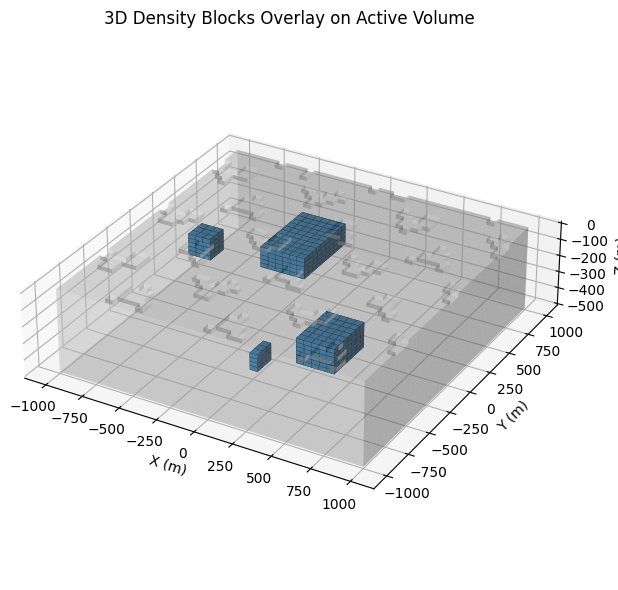

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_density_contrast_3D_voxels(mesh, ind_active, blocks_mask):
    """
    Plot 3D voxel grid showing:
      - semi-transparent active (earth) volume
      - solid blocks overlay for density anomalies
    """
    # --- 1. Full-size masks ---
    full_active = np.zeros(mesh.nC, dtype=bool)
    full_active[ind_active] = True

    full_blocks = np.zeros(mesh.nC, dtype=bool)
    full_blocks[ind_active] = blocks_mask

    # --- 2. Reshape to 3D (Fortran order) ---
    active_vol = full_active.reshape(mesh.shape_cells, order="F")
    block_vol  = full_blocks.reshape(mesh.shape_cells, order="F")

    # --- 3. Compute voxel edge grids ---
    x_edges = mesh.x0[0] + np.r_[0.0, np.cumsum(mesh.h[0])]
    y_edges = mesh.x0[1] + np.r_[0.0, np.cumsum(mesh.h[1])]
    z_edges = mesh.x0[2] + np.r_[0.0, np.cumsum(mesh.h[2])]
    X, Y, Z = np.meshgrid(x_edges, y_edges, z_edges, indexing="ij")

    # --- 4. Plot ---
    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(111, projection="3d")

    # Base active domain (semi-transparent gray)
    ax.voxels(
        X, Y, Z, active_vol,
        facecolors="lightgray",
        edgecolor="none",
        alpha=0.30
    )

    # Overlay blocks (solid blue)
    ax.voxels(
        X, Y, Z, block_vol,
        facecolors="tab:blue",
        edgecolor="k",
        linewidth=0.2,
        alpha=0.9
    )

    # --- 5. Formatting ---
    ax.set_box_aspect((np.sum(mesh.h[0]), np.sum(mesh.h[1]), np.sum(mesh.h[2])))
    ax.set_xlabel("X (m)")
    ax.set_ylabel("Y (m)")
    ax.set_zlabel("Z (m)")
    ax.set_title("3D Density Blocks Overlay on Active Volume")
    plt.tight_layout()
    plt.show()

plot_density_contrast_3D_voxels(mesh, ind_active, blocks_mask)

/tmp/ipykernel_8845/234972538.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  rgba = cm.get_cmap(cmap)(t)


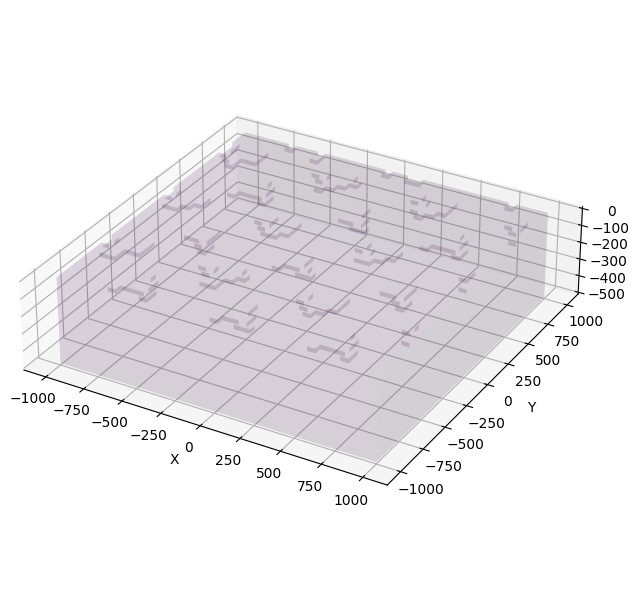

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

def plot_voxels_by_density_simple(
    mesh,
    ind_active,
    active_density,
    mode="abs",          # "abs" → use |density| for color/alpha, "raw" → use raw values
    cmap="viridis",
    alpha_min=0.05,
    alpha_max=0.95,
    edgecolor=None,
    linewidth=0.0,
    figsize=(7,6),
):
    """
    Minimal voxel renderer for SimPEG/discretize TensorMesh models.
    - Draws only active cells; opacity encodes density magnitude (or value).
    """
    # Expand active densities to full cell vector and reshape (discretize uses Fortran order)
    full = np.full(mesh.nC, np.nan)
    full[ind_active] = np.asarray(active_density, float)
    grid = full.reshape(mesh.shape_cells, order="F")

    # Build cell-edge grids once so physical sizes are correct
    x = mesh.x0[0] + np.r_[0.0, np.cumsum(mesh.h[0])]
    y = mesh.x0[1] + np.r_[0.0, np.cumsum(mesh.h[1])]
    z = mesh.x0[2] + np.r_[0.0, np.cumsum(mesh.h[2])]
    X, Y, Z = np.meshgrid(x, y, z, indexing="ij")

    filled = ~np.isnan(grid)
    vals = np.abs(np.nan_to_num(grid)) if mode == "abs" else np.nan_to_num(grid)

    if np.any(filled):
        vmin = float(np.nanmin(vals[filled]))
        vmax = float(np.nanmax(vals[filled]))
        if not np.isfinite(vmin): vmin = 0.0
        if not np.isfinite(vmax) or vmax <= vmin: vmax = vmin + 1e-9
    else:
        vmin, vmax = 0.0, 1.0

    # Normalize → color + alpha
    t = np.clip((vals - vmin) / (vmax - vmin), 0.0, 1.0)
    rgba = cm.get_cmap(cmap)(t)
    rgba[..., 3] = alpha_min + (alpha_max - alpha_min) * t
    rgba[np.isnan(grid)] = 0.0  # fully transparent for inactive cells

    # Plot
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection="3d")
    ax.voxels(X, Y, Z, filled, facecolors=rgba, edgecolor=edgecolor, linewidth=linewidth)

    ax.set_box_aspect((np.sum(mesh.h[0]), np.sum(mesh.h[1]), np.sum(mesh.h[2])))
    ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
    plt.tight_layout()
    plt.show()

plot_voxels_by_density_simple(
    mesh, ind_active, true_model,
    mode="abs", cmap="viridis",
    alpha_min=0.08, alpha_max=0.98,
    edgecolor=None, linewidth=0.0,
)

In [5]:
import numpy as np
import pyvista as pv
from matplotlib import cm

def plot_voxels_pyvista_cells(
    mesh,
    ind_active,
    active_density,
    mode="abs",          # "abs": alpha from |density|; "raw": from signed value
    cmap="viridis",
    alpha_min=0.05,
    alpha_max=0.95,
    background="white",
    cpos="iso",
    show_edges=False,
):
    # 1) Full vector -> Fortran reshaped cube
    full = np.full(mesh.nC, np.nan, dtype=float)
    full[ind_active] = np.asarray(active_density, float)
    dens3 = full.reshape(mesh.shape_cells, order="F")
    vals = np.abs(np.nan_to_num(dens3)) if mode == "abs" else np.nan_to_num(dens3)

    # 2) Rectilinear grid from cell edges
    x = mesh.x0[0] + np.r_[0.0, np.cumsum(mesh.h[0])]
    y = mesh.x0[1] + np.r_[0.0, np.cumsum(mesh.h[1])]
    z = mesh.x0[2] + np.r_[0.0, np.cumsum(mesh.h[2])]
    grid = pv.RectilinearGrid(x, y, z)

    # 3) Attach cell scalars; mark actives
    grid.cell_data["density"] = dens3.ravel(order="F")
    active_ids = np.where(np.isfinite(grid.cell_data["density"]))[0]

    # 4) Keep only active cells as solid hexahedra (true voxels)
    solid = grid.cast_to_unstructured_grid().extract_cells(active_ids)

    # 5) Per-cell RGBA (alpha ~ density magnitude)
    d = solid.cell_data["density"]
    m = np.abs(np.nan_to_num(d)) if mode == "abs" else np.nan_to_num(d)
    if m.size and np.nanmax(m) > 0:
        t = (m - np.nanmin(m)) / max(1e-12, (np.nanmax(m) - np.nanmin(m)))
    else:
        t = np.zeros_like(m)

    # colormap → rgba in [0,1], then set alpha range
    rgba = cm.get_cmap(cmap)(t)
    rgba[:, 3] = alpha_min + (alpha_max - alpha_min) * t
    rgba_u8 = (rgba * 255).astype(np.uint8)
    solid.cell_data["rgba"] = rgba_u8  # per-cell colors with alpha

    # 6) Plot as voxels (cells), not a volume
    p = pv.Plotter()
    p.set_background(background)
    p.add_mesh(
        solid,
        scalars="rgba",
        rgba=True,                 # interpret scalars as RGBA
        show_edges=show_edges,
        ambient=1.0,               # flatter shading so colors/alpha read clearly
        lighting=False,            # optional: turn off lighting for clean look
    )
    p.add_axes(); p.show_grid(); p.camera_position = cpos
    p.show()

plot_voxels_pyvista_cells(mesh, ind_active, true_model)


/tmp/ipykernel_8845/67957359.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  rgba = cm.get_cmap(cmap)(t)
MESA: error: ZINK: failed to choose pdev
glx: failed to create drisw screen


Widget(value='<iframe src="http://localhost:43315/index.html?ui=P_0x7a575ba90d40_0&reconnect=auto" class="pyvi…